In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# =========================
# LOAD DATASET
# =========================

train_path = "../data/raw/Tuesday-WorkingHours.pcap_ISCX.csv"

test_path = "../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"


print("[INFO] Loading datasets...")


train_df = pd.read_csv(train_path)

test_df = pd.read_csv(test_path)


print("Train Shape:", train_df.shape)

print("Test Shape :", test_df.shape)

[INFO] Loading datasets...
Train Shape: (445909, 79)
Test Shape : (225745, 79)


In [3]:
# =========================
# DISPLAY DATA
# =========================

train_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,179,0,89.5,103.345698,1246875.000,17187.500000,64.000000,135.557286,445,1,640,106.666667,194.325157,497,1,538,179.333333,303.686242,530,4,0,0,0,0,164,104,10937.500000,6250.000000,0,220,66.500000,99.001837,9801.363636,0,0,0,1,0,0,0,0,0,72.545455,62.857143,89.5,164,0,0,0,0,0,0,7,440,4,358,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,1472,0,736.0,849.859596,3937777.778,14444.444440,75.000000,192.795228,684,1,900,112.500000,252.411229,734,1,766,255.333333,435.323252,758,3,0,0,0,0,204,104,10000.000000,4444.444444,0,1472,253.142857,527.434262,278186.901100,0,0,0,1,0,0,0,0,0,272.615385,66.666667,736.0,204,0,0,0,0,0,0,9,600,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,1415,0,707.5,816.950631,4652282.158,9128.630705,120.500000,236.433336,777,1,1205,200.833333,397.058392,1008,1,927,309.000000,491.647231,876,1,0,0,0,0,164,104,5809.128631,3319.502075,0,1415,467.166667,690.098917,476236.515200,0,0,0,1,0,0,0,0,0,509.636364,396.571429,707.5,164,0,0,0,0,0,0,7,2776,4,2830,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,185,0,92.5,106.809800,1608610.568,21526.418790,51.100000,90.767652,299,1,511,85.166667,131.900594,349,1,462,154.000000,224.719826,412,1,0,0,0,0,164,104,13698.630140,7827.788650,0,226,68.500000,101.933579,10390.454550,0,0,0,1,0,0,0,0,0,74.727273,64.571429,92.5,164,0,0,0,0,0,0,7,452,4,370,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,1472,0,736.0,849.859596,4600258.732,16817.593790,64.416667,148.698266,531,1,773,96.625000,196.665733,580,1,675,225.000000,348.901132,627,1,0,0,0,0,204,104,11642.949550,5174.644243,0,1472,254.000000,527.520762,278278.153800,0,0,0,1,0,0,0,0,0,273.538461,68.000000,736.0,204,0,0,0,0,0,0,9,612,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# =========================
# DATASET INFO
# =========================

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445909 entries, 0 to 445908
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             445909 non-null  int64  
 1    Flow Duration                445909 non-null  int64  
 2    Total Fwd Packets            445909 non-null  int64  
 3    Total Backward Packets       445909 non-null  int64  
 4   Total Length of Fwd Packets   445909 non-null  int64  
 5    Total Length of Bwd Packets  445909 non-null  int64  
 6    Fwd Packet Length Max        445909 non-null  int64  
 7    Fwd Packet Length Min        445909 non-null  int64  
 8    Fwd Packet Length Mean       445909 non-null  float64
 9    Fwd Packet Length Std        445909 non-null  float64
 10  Bwd Packet Length Max         445909 non-null  int64  
 11   Bwd Packet Length Min        445909 non-null  int64  
 12   Bwd Packet Length Mean       445909 non-nul

In [5]:
# =========================
# CHECK NULL VALUES
# =========================

null_values = train_df.isnull().sum()

null_values[null_values > 0]

Flow Bytes/s    201
dtype: int64

In [6]:
# =========================
# CHECK INFINITY
# =========================

numeric_df = train_df.select_dtypes(include=[np.number])

infinity_count = np.isinf(numeric_df).sum()

infinity_count[infinity_count > 0]

Flow Bytes/s        63
 Flow Packets/s    264
dtype: int64

In [7]:
# =========================
# CLEAN COLUMN NAMES
# =========================

train_df.columns = train_df.columns.str.strip()

test_df.columns = test_df.columns.str.strip()

print(train_df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [8]:
# =========================
# REPLACE INFINITY
# =========================

train_df.replace([np.inf, -np.inf], np.nan, inplace=True)

test_df.replace([np.inf, -np.inf], np.nan, inplace=True)


# =========================
# DROP NaN
# =========================

train_df.dropna(inplace=True)

test_df.dropna(inplace=True)


print("Train Shape:", train_df.shape)

print("Test Shape :", test_df.shape)

Train Shape: (445645, 79)
Test Shape : (225711, 79)


In [9]:
# =========================
# LABEL DISTRIBUTION
# =========================

train_df['Label'].value_counts()

Label
BENIGN         431813
FTP-Patator      7935
SSH-Patator      5897
Name: count, dtype: int64

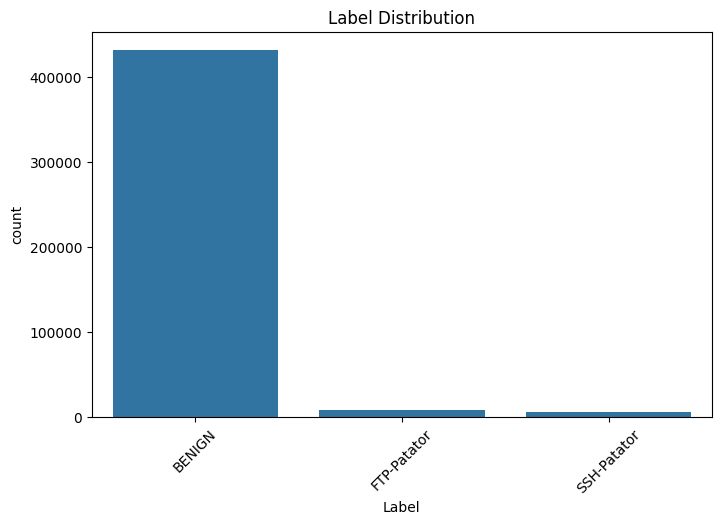

In [10]:
# =========================
# PLOT LABEL DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

sns.countplot(x='Label', data=train_df)

plt.title("Label Distribution")

plt.xticks(rotation=45)

plt.show()

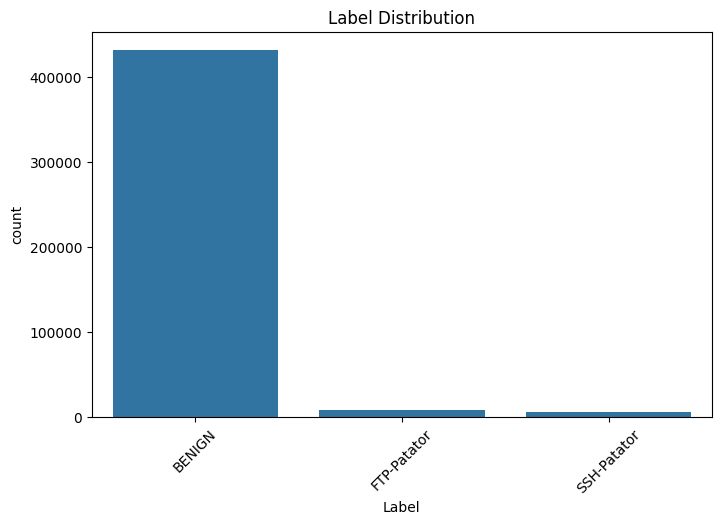

In [11]:
# =========================
# PLOT LABEL DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

sns.countplot(x='Label', data=train_df)

plt.title("Label Distribution")

plt.xticks(rotation=45)

plt.show()

In [12]:
# =========================
# ENCODE LABEL
# =========================

train_df['Label'] = train_df['Label'].apply(

    lambda x: 0 if x == 'BENIGN' else 1
)

test_df['Label'] = test_df['Label'].apply(

    lambda x: 0 if x == 'BENIGN' else 1
)


train_df['Label'].value_counts()

Label
0    431813
1     13832
Name: count, dtype: int64

In [13]:
# =========================
# SELECT FEATURES
# =========================

selected_features = [

    'Flow Duration',

    'Total Fwd Packets',

    'Total Backward Packets',

    'SYN Flag Count',

    'ACK Flag Count',

    'Average Packet Size',

    'Packet Length Mean'
]


selected_features

['Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'SYN Flag Count',
 'ACK Flag Count',
 'Average Packet Size',
 'Packet Length Mean']

In [14]:
# =========================
# FEATURE STATISTICS
# =========================

train_df[selected_features].describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,SYN Flag Count,ACK Flag Count,Average Packet Size,Packet Length Mean
count,4.456450e+05,445645.000000,445645.000000,445645.000000,445645.000000,445645.000000,445645.000000
mean,1.078582e+07,11.806483,13.915244,0.060618,0.291371,121.307053,107.678515
std,2.956387e+07,867.329183,1172.508644,0.238628,0.454395,196.543432,190.527513
min,-4.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.860000e+02,2.000000,1.000000,0.000000,0.000000,6.200000,5.285714
50%,3.129800e+04,2.000000,2.000000,0.000000,0.000000,74.000000,58.600000
75%,4.696170e+05,4.000000,2.000000,0.000000,1.000000,120.000000,91.400000
max,1.200000e+08,206446.000000,276072.000000,1.000000,1.000000,3893.333333,3337.142857


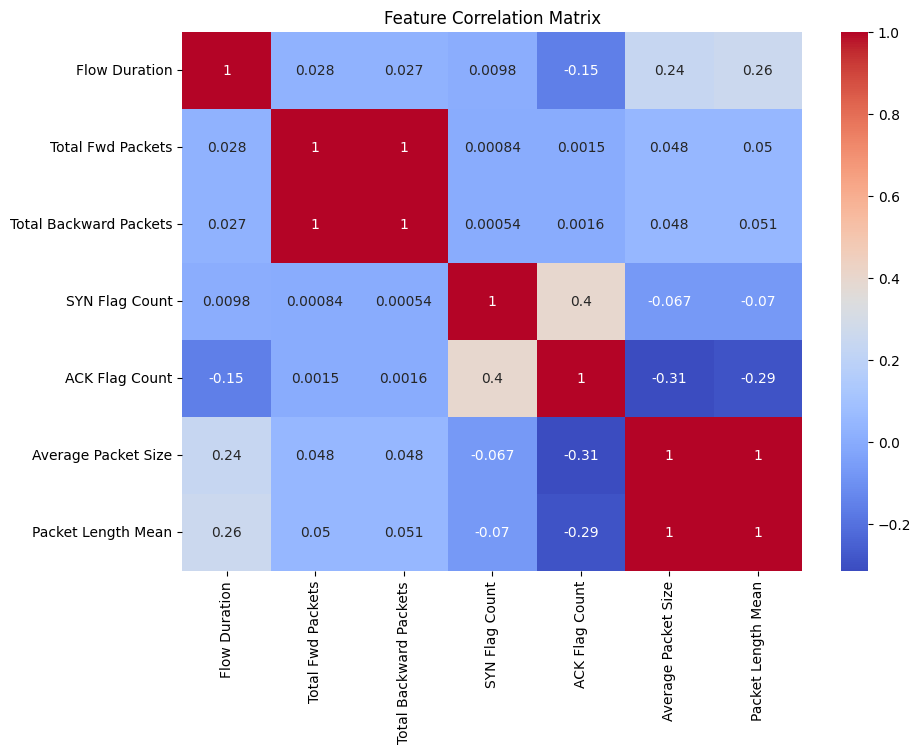

In [15]:
# =========================
# CORRELATION MATRIX
# =========================

corr_matrix = train_df[selected_features].corr()

plt.figure(figsize=(10,7))

sns.heatmap(

    corr_matrix,

    annot=True,

    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

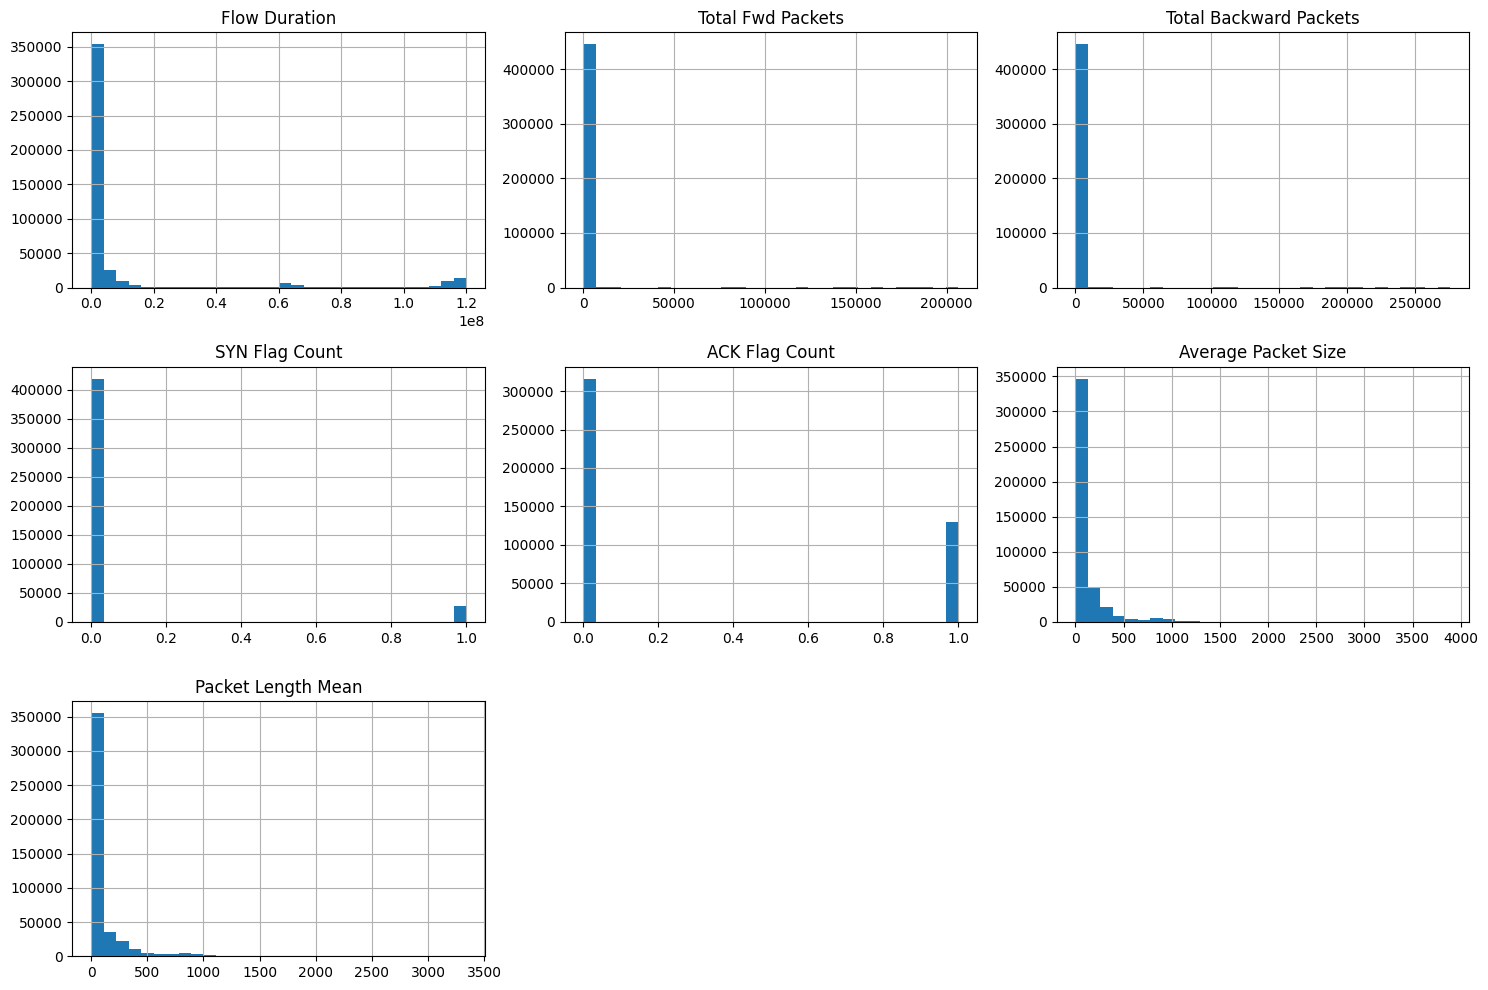

In [16]:
# =========================
# FEATURE HISTOGRAMS
# =========================

train_df[selected_features].hist(

    figsize=(15,10),

    bins=30
)

plt.tight_layout()

plt.show()

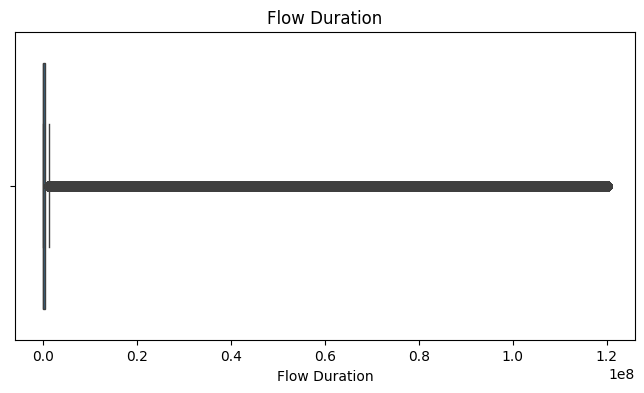

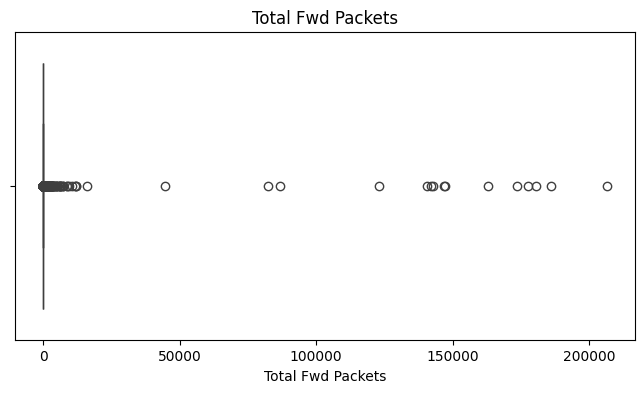

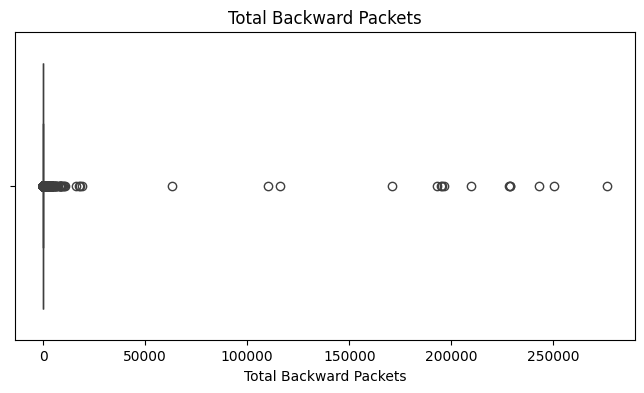

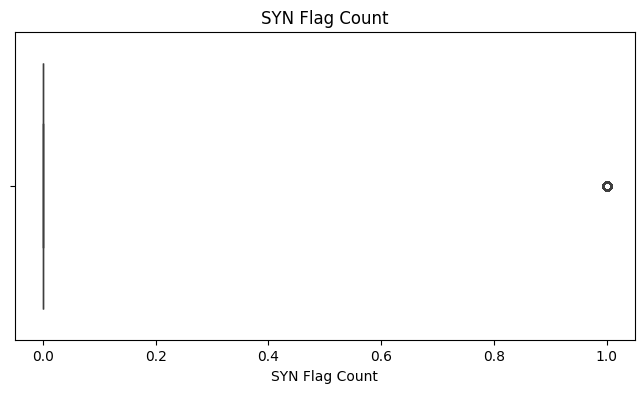

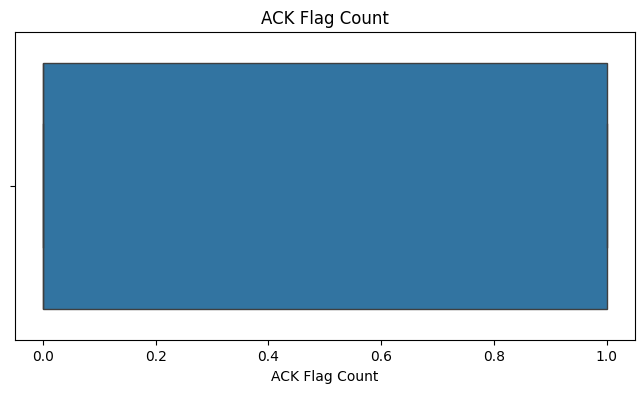

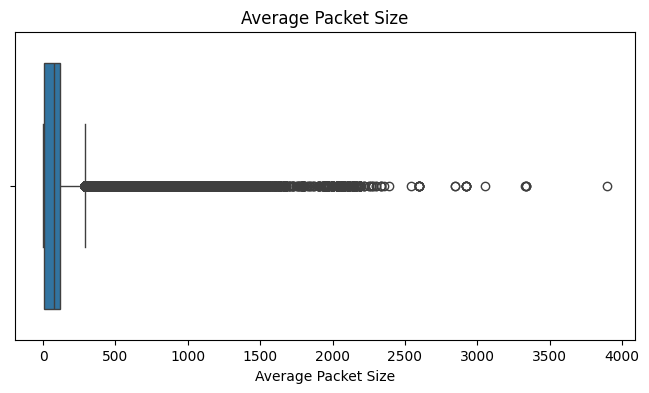

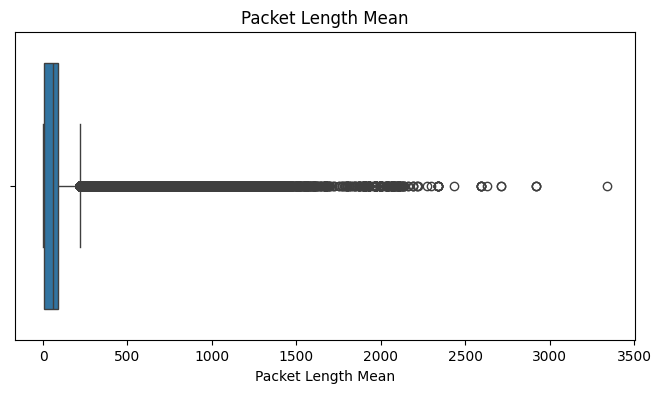

In [17]:
# =========================
# FEATURE BOXPLOTS
# =========================

for feature in selected_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(

        x=train_df[feature]
    )

    plt.title(feature)

    plt.show()

In [18]:
# =========================
# SAVE CLEAN DATASETS
# =========================

train_df.to_csv(

    "../data/processed/train_clean.csv",

    index=False
)

test_df.to_csv(

    "../data/processed/test_clean.csv",

    index=False
)


print("[INFO] Clean datasets saved successfully")

[INFO] Clean datasets saved successfully


In [19]:
# =========================
# FINAL CHECK
# =========================

print("Train Shape:", train_df.shape)

print("Test Shape :", test_df.shape)

print("\nSelected Features:")

print(selected_features)

Train Shape: (445645, 79)
Test Shape : (225711, 79)

Selected Features:
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'SYN Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Packet Length Mean']
